# Семинар 2. Исследование методов линейной регрессии

#### Критерий оценивания:
#### Пункт 14: максимум 0,5 балла
#### Пункт 15: максимум 0,5 балла

#### Итого за работу: максимум 1 балл
#### P.S. пункты 14 и 15 без пунктов 1-13 не засчитываются, ответы на вопросы из ИИ не засчитываются

### Данные и обозначения

В работе используется приложенный `auto_dataset.csv`; предсказывается столбец `price`.
Для повторного запуска CSV должен лежать рядом с ноутбуком. Нужны Python 3,
NumPy, pandas, matplotlib и scikit-learn 1.2 или новее.

`Loss` ниже — это **MSE**, как в лекции: среднее квадратов ошибок.
VGD — сокращённое название `VanillaGradientDescent` из лекции.
Исходные задания сохранены; результаты вычисляются кодом, а не заданы вручную.

1. Загрузите датасет и выведите на экран первые несколько строк

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from threadpoolctl import threadpool_limits

RANDOM_STATE = 42
DATA_PATH = Path("auto_dataset.csv")
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        "Положите auto_dataset.csv в рабочую папку рядом с ноутбуком."
    )

df = pd.read_csv(DATA_PATH)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов.")
print(f"Пропусков: {int(df.isna().sum().sum())}.")
display(df.head())

Размер датасета: 1000 строк, 10 столбцов.
Пропусков: 0.


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


2. Разбейте выборку на признаки и ответы. Закодируйте категориальные признаки.

In [2]:
# Предсказываем цену автомобиля. Все остальные столбцы — признаки.
X_raw = df.drop(columns="price")
y = df["price"].to_numpy(dtype=float)

categorical_features = X_raw.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X_raw.select_dtypes(include="number").columns.tolist()

# Категории превратим в отдельные столбцы из нулей и единиц.
# Числовые признаки приведём к одному масштабу.
preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
     categorical_features),
], remainder="drop", sparse_threshold=0.0)

print("Ответ: price")
print("Числовые признаки:", ", ".join(numeric_features))
print("Категориальные признаки:", ", ".join(categorical_features))
print("Кодировщик подготовлен. Обучаю его в пункте 3 только на train,")
print("чтобы сведения из val и test не участвовали в подготовке train.")

Ответ: price
Числовые признаки: powerPS, kilometer, autoAgeMonths
Категориальные признаки: brand, model, vehicleType, gearbox, fuelType, notRepairedDamage
Кодировщик подготовлен. Обучаю его в пункте 3 только на train,
чтобы сведения из val и test не участвовали в подготовке train.


3. Разбейте датасет на train val test в отношении 8:1:1

In [3]:
# Сначала выделяем 80% для обучения, затем делим оставшиеся 20% пополам.
X_train_raw, X_holdout_raw, y_train, y_holdout = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_holdout_raw, y_holdout, test_size=0.5, random_state=RANDOM_STATE
)

X_train_encoded = preprocessor.fit_transform(X_train_raw)
X_val_encoded = preprocessor.transform(X_val_raw)
X_test_encoded = preprocessor.transform(X_test_raw)

# Столбец единиц нужен для свободного коэффициента в записи y_pred = X @ w.
def add_bias(X):
    return np.ascontiguousarray(np.column_stack([np.ones(len(X)), X]), dtype=float)

X_train = add_bias(X_train_encoded)
X_val = add_bias(X_val_encoded)
X_test = add_bias(X_test_encoded)
feature_names = ["bias", *preprocessor.get_feature_names_out()]

# Проверяем, что строки из разных частей не пересекаются.
assert set(X_train_raw.index).isdisjoint(X_val_raw.index)
assert set(X_train_raw.index).isdisjoint(X_test_raw.index)
assert set(X_val_raw.index).isdisjoint(X_test_raw.index)
assert (len(y_train), len(y_val), len(y_test)) == (800, 100, 100)
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1]

display(pd.DataFrame({
    "Выборка": ["train", "val", "test"],
    "Объектов": [len(y_train), len(y_val), len(y_test)],
    "Доля": [len(y_train) / len(y), len(y_val) / len(y), len(y_test) / len(y)],
    "Признаков со свободным коэффициентом": [X_train.shape[1]] * 3,
}))
print("Первые пять строк и восемь столбцов после преобразований:")
display(pd.DataFrame(X_train, columns=feature_names).iloc[:5, :8])

,Выборка,Объектов,Доля,Признаков со свободным коэффициентом
0,train,800,0.8,195
1,val,100,0.1,195
2,test,100,0.1,195


Первые пять строк и восемь столбцов после преобразований:


,bias,numeric__powerPS,numeric__kilometer,numeric__autoAgeMonths,categorical__brand_alfa_romeo,categorical__brand_audi,categorical__brand_bmw,categorical__brand_chevrolet
0,1.0,1.617418,0.666505,-0.023001,0.0,1.0,0.0,0.0
1,1.0,-0.946575,0.043312,1.289524,0.0,0.0,0.0,0.0
2,1.0,-0.521965,-2.075543,-1.654100,0.0,0.0,0.0,0.0
3,1.0,0.490568,-0.579881,0.550432,0.0,0.0,0.0,0.0
4,1.0,-0.179010,0.666505,-0.647406,0.0,0.0,0.0,0.0


In [4]:
# Общие функции для пунктов 4–14.
# В лекции TimeDecayLR: eta_k = lambda * (s0 / (s0 + k))^p,
# где s0 = 1, p = 0.5. Для всех методов выполняем ровно 5000 итераций.
MAX_ITER = 5000
STEP_GRID = np.logspace(-5, 0, 6)  # 10^-5, ..., 1
S0 = 1.0
P = 0.5


class GradientLinearRegression:
    def __init__(
        self,
        method,
        step,
        decay=False,
        max_iter=MAX_ITER,
        batch_size=32,
        s0=S0,
        p=P,
        alpha=0.9,
        beta1=0.9,
        beta2=0.999,
        eps=1e-8,
        random_state=RANDOM_STATE,
        track_history=False,
    ):
        self.method = method
        self.step = float(step)
        self.decay = decay
        self.max_iter = int(max_iter)
        self.batch_size = int(batch_size)
        self.s0 = float(s0)
        self.p = float(p)
        self.alpha = float(alpha)
        self.beta1 = float(beta1)
        self.beta2 = float(beta2)
        self.eps = float(eps)
        self.random_state = random_state
        self.track_history = track_history

    def _learning_rate(self, k):
        if self.decay:
            return self.step * (self.s0 / (self.s0 + k)) ** self.p
        return self.step

    def fit(self, X, y):
        X = np.ascontiguousarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n, d = X.shape

        self.w_ = np.zeros(d, dtype=float)
        self.loss_history_ = []
        rng = np.random.default_rng(self.random_state)

        # Для полного градиента заранее считаем части формулы MSE.
        # Это не меняет математику из лекции, а только ускоряет вычисления.
        A = (X.T @ X) / n
        c = (X.T @ y) / n
        y2 = float(np.mean(y ** 2))

        h = np.zeros(d, dtype=float)  # Momentum
        m = np.zeros(d, dtype=float)  # Adam: первый момент
        v = np.zeros(d, dtype=float)  # Adam: второй момент

        if self.method == "SAG":
            grad_memory = np.zeros((n, d), dtype=float)
            g_bar = np.zeros(d, dtype=float)

        with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
            for k in range(self.max_iter):
                # Q_train(w_k) для итогового графика сходимости.
                if self.track_history:
                    Aw = A @ self.w_
                    loss = float(self.w_ @ Aw - 2.0 * c @ self.w_ + y2)
                    self.loss_history_.append(
                        max(loss, 0.0) if np.isfinite(loss) else np.inf
                    )

                eta = self._learning_rate(k)

                if self.method in ("VGD", "Momentum", "Adam"):
                    # grad MSE = 2/n * X.T @ (Xw - y)
                    grad = 2.0 * (A @ self.w_ - c)

                    if self.method == "VGD":
                        self.w_ -= eta * grad

                    elif self.method == "Momentum":
                        # h_(k+1) = 0.9*h_k + eta_k*grad
                        # w_(k+1) = w_k - h_(k+1)
                        h = self.alpha * h + eta * grad
                        self.w_ -= h

                    else:  # Adam
                        t = k + 1
                        m = self.beta1 * m + (1.0 - self.beta1) * grad
                        v = self.beta2 * v + (1.0 - self.beta2) * (grad ** 2)
                        m_hat = m / (1.0 - self.beta1 ** t)
                        v_hat = v / (1.0 - self.beta2 ** t)
                        self.w_ -= eta * m_hat / (np.sqrt(v_hat) + self.eps)

                elif self.method == "SGD":
                    # Градиент по случайному батчу B_k.
                    b = min(self.batch_size, n)
                    idx = rng.choice(n, size=b, replace=False)
                    X_b = X[idx]
                    y_b = y[idx]
                    grad = (2.0 / b) * (X_b.T @ (X_b @ self.w_ - y_b))
                    self.w_ -= eta * grad

                elif self.method == "SAG":
                    # Пересчитываем градиент одного случайного объекта и
                    # обновляем средний сохранённый градиент, как в лекции.
                    j = int(rng.integers(0, n))
                    x_j = X[j]
                    new_grad = 2.0 * (x_j @ self.w_ - y[j]) * x_j
                    g_bar += (new_grad - grad_memory[j]) / n
                    grad_memory[j] = new_grad
                    self.w_ -= eta * g_bar

                else:
                    raise ValueError(f"Неизвестный метод: {self.method}")

                # Если конкретный слишком большой шаг разошёлся, он всё равно
                # не сможет стать лучшим по Loss_val. Историю дополняем до 5000.
                if not np.all(np.isfinite(self.w_)):
                    self.w_[:] = np.nan
                    if self.track_history:
                        self.loss_history_.extend(
                            [np.inf] * (self.max_iter - k - 1)
                        )
                    break

        # По условию сравниваем модели при одинаковом лимите — 5000 итераций.
        self.n_iter_ = self.max_iter
        return self

    def predict(self, X):
        return np.asarray(X, dtype=float) @ self.w_


def calculate_metrics(model, X, y):
    y_pred = model.predict(X)
    if not np.all(np.isfinite(y_pred)):
        return np.inf, -np.inf
    return mean_squared_error(y, y_pred), r2_score(y, y_pred)


experiments = {}


def investigate(method, decay=False):
    rows = []

    # Для каждого значения шага обучаем модель на train и выбираем шаг
    # ТОЛЬКО по минимальному Loss_val, как требует лекция.
    with threadpool_limits(limits=1):
        for step in STEP_GRID:
            model = GradientLinearRegression(
                method=method,
                step=step,
                decay=decay,
                max_iter=MAX_ITER,
                track_history=False,
            ).fit(X_train, y_train)

            loss_train, r2_train = calculate_metrics(model, X_train, y_train)
            loss_val, _ = calculate_metrics(model, X_val, y_val)

            rows.append({
                "step": float(step),
                "Loss_train": loss_train,
                "R²_train": r2_train,
                "Loss_val": loss_val,
            })

        search_table = pd.DataFrame(rows)
        finite = search_table[np.isfinite(search_table["Loss_val"])]
        if finite.empty:
            raise RuntimeError(f"Для {method} не нашлось устойчивого шага.")

        best_idx = finite["Loss_val"].idxmin()
        best_step = float(search_table.loc[best_idx, "step"])

        # После выбора шага переобучаем выбранную модель тем же способом,
        # теперь сохраняем Loss_train на каждой из 5000 итераций для графика.
        best_model = GradientLinearRegression(
            method=method,
            step=best_step,
            decay=decay,
            max_iter=MAX_ITER,
            track_history=True,
        ).fit(X_train, y_train)

        loss_train, r2_train = calculate_metrics(best_model, X_train, y_train)
        loss_val, _ = calculate_metrics(best_model, X_val, y_val)
        loss_test, r2_test = calculate_metrics(best_model, X_test, y_test)

    result = {
        "method": method,
        "decay": decay,
        "best_step": best_step,
        "Loss_train": loss_train,
        "Loss_val": loss_val,
        "Loss_test": loss_test,
        "R²_train": r2_train,
        "R²_test": r2_test,
        "iterations": MAX_ITER,
        "best_model": best_model,
        "search_table": search_table,
    }
    experiments[(method, decay)] = result

    mode_name = "TimeDecayLR" if decay else "постоянный шаг"
    print(f"{method} — {mode_name}")
    display(search_table.style.format({
        "step": "{:.5g}",
        "Loss_train": "{:,.2f}",
        "R²_train": "{:.6f}",
        "Loss_val": "{:,.2f}",
    }).hide(axis="index"))
    print(f"Лучший шаг по минимальному Loss_val: {best_step:g}")
    print(f"Loss_train = {loss_train:,.2f}")
    print(f"R²_train = {r2_train:.6f}")
    print(f"Loss_val = {loss_val:,.2f}")
    print(f"Loss_test = {loss_test:,.2f}")
    print(f"R²_test = {r2_test:.6f}")
    print(f"Число итераций = {MAX_ITER}")

    plt.figure(figsize=(7.5, 4.2))
    plt.plot(search_table["step"], search_table["Loss_val"], marker="o")
    plt.xscale("log")
    plt.xlabel("lambda" if decay else "eta")
    plt.ylabel("Loss_val (MSE)")
    plt.title(f"{method}: выбор шага ({mode_name})")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return result


4. Исследуйте VGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

VGD — постоянный шаг


step,Loss_train,R²_train,Loss_val
1e-05,"77,006,808.39",-0.265260,"74,560,600.57"
0.0001,"23,937,296.05",0.606698,"23,164,504.97"
0.001,"18,141,742.44",0.701922,"20,955,625.10"
0.01,"15,197,556.30",0.750297,"18,266,802.32"
0.1,"12,626,987.61",0.792532,"16,693,957.37"
1,inf,-inf,inf


Лучший шаг по минимальному Loss_val: 0.1
Loss_train = 12,626,987.61
R²_train = 0.792532
Loss_val = 16,693,957.37
Loss_test = 27,835,243.07
R²_test = 0.600857
Число итераций = 5000


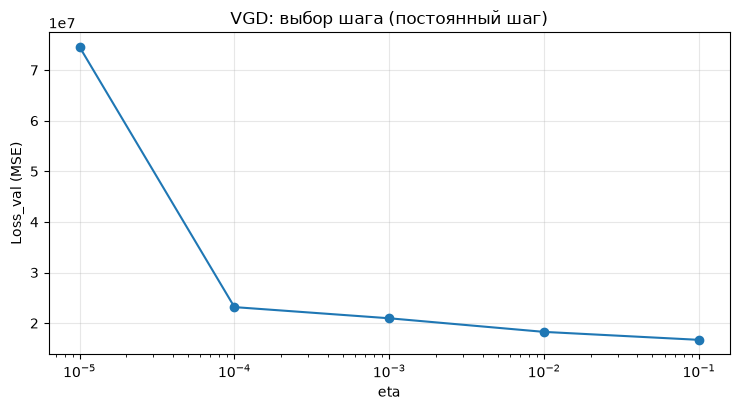

In [5]:
result_vgd_constant = investigate("VGD", decay=False)

5. Исследуйте VGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

VGD — TimeDecayLR


step,Loss_train,R²_train,Loss_val
1e-05,"108,109,751.52",-0.776297,"106,031,537.53"
0.0001,"98,396,896.53",-0.616710,"96,197,392.36"
0.001,"48,232,162.09",0.207521,"45,694,062.95"
0.01,"19,779,950.45",0.675006,"21,350,212.45"
0.1,"17,050,110.24",0.719858,"19,977,535.72"
1,"13,736,414.90",0.774304,"17,056,178.30"


Лучший шаг по минимальному Loss_val: 1
Loss_train = 13,736,414.90
R²_train = 0.774304
Loss_val = 17,056,178.30
Loss_test = 26,457,141.65
R²_test = 0.620618
Число итераций = 5000


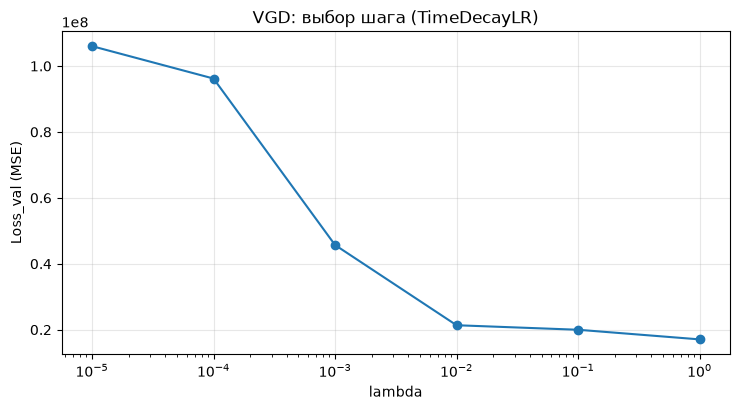

In [6]:
result_vgd_decay = investigate("VGD", decay=True)

6. Исследуйте SGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

SGD — постоянный шаг


step,Loss_train,R²_train,Loss_val
1e-05,"76,961,099.82",-0.264509,"74,516,343.74"
0.0001,"23,908,901.74",0.607165,"23,149,570.01"
0.001,"18,122,008.89",0.702246,"20,975,912.49"
0.01,"15,194,584.76",0.750345,"18,376,392.17"
0.1,"13,180,140.32",0.783444,"17,080,144.85"
1,inf,-inf,inf


Лучший шаг по минимальному Loss_val: 0.1
Loss_train = 13,180,140.32
R²_train = 0.783444
Loss_val = 17,080,144.85
Loss_test = 28,269,777.97
R²_test = 0.594626
Число итераций = 5000


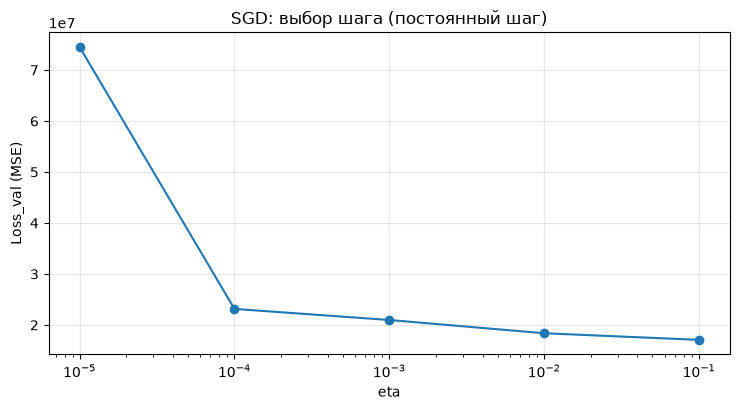

In [7]:
result_sgd_constant = investigate("SGD", decay=False)

7. Исследуйте SGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

SGD — TimeDecayLR


step,Loss_train,R²_train,Loss_val
1e-05,"108,099,150.10",-0.776123,"106,021,135.66"
0.0001,"98,302,407.74",-0.615158,"96,105,150.41"
0.001,"47,900,264.25",0.212975,"45,394,559.22"
0.01,"19,710,600.74",0.676145,"21,386,078.59"
0.1,"17,040,102.42",0.720023,"20,037,229.39"
1,"3,796,238,215.19",-61.374092,"4,793,175,702.64"


Лучший шаг по минимальному Loss_val: 0.1
Loss_train = 17,040,102.42
R²_train = 0.720023
Loss_val = 20,037,229.39
Loss_test = 24,700,352.51
R²_test = 0.645810
Число итераций = 5000


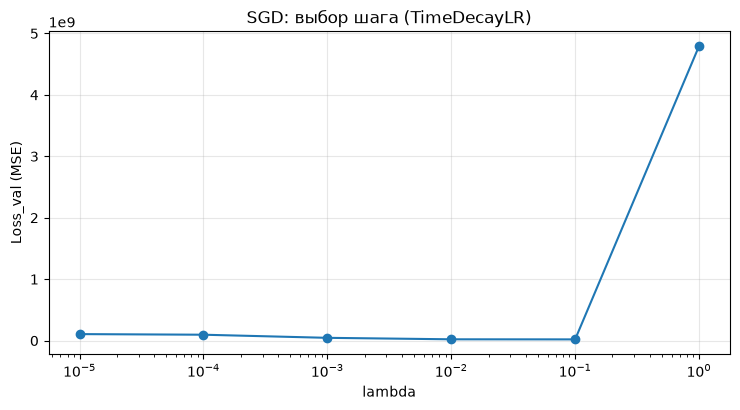

In [8]:
result_sgd_decay = investigate("SGD", decay=True)

8. Исследуйте SAG с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

SAG — постоянный шаг


step,Loss_train,R²_train,Loss_val
1e-05,"80,693,367.40",-0.325832,"78,268,136.81"
0.0001,"23,960,308.72",0.606320,"22,977,017.27"
0.001,"18,379,258.63",0.698020,"21,302,343.04"
0.01,"16,358,293.52",0.731225,"17,923,847.38"
0.1,"1,135,635,524.20",-17.659059,"895,605,664.31"
1,"14,814,650,394,512,903,212,661,822,246,092,800.00",-243412113112952112267919360.000000,"10,453,826,087,444,725,744,566,026,968,760,320.00"


Лучший шаг по минимальному Loss_val: 0.01
Loss_train = 16,358,293.52
R²_train = 0.731225
Loss_val = 17,923,847.38
Loss_test = 26,571,773.98
R²_test = 0.618974
Число итераций = 5000


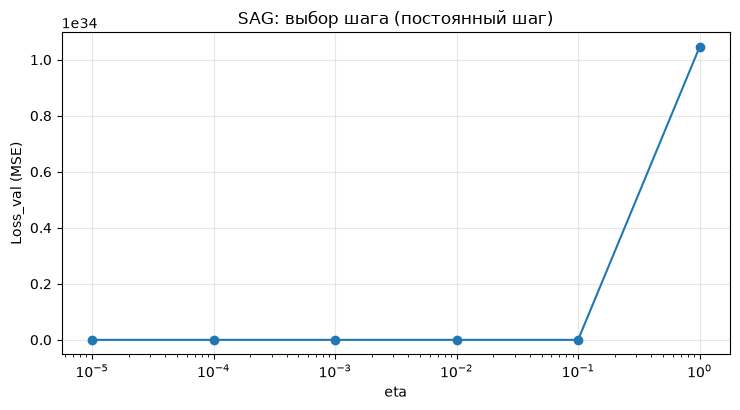

In [9]:
result_sag_constant = investigate("SAG", decay=False)

9. Исследуйте SAG с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

SAG — TimeDecayLR


step,Loss_train,R²_train,Loss_val
1e-05,"108,524,717.85",-0.783115,"106,451,620.23"
0.0001,"102,057,938.66",-0.676863,"99,902,584.17"
0.001,"59,436,310.66",0.023432,"56,798,360.26"
0.01,"20,444,107.21",0.664093,"21,603,112.77"
0.1,"17,636,107.64",0.710230,"20,191,040.61"
1,"17,745,646.76",0.708430,"21,778,859.22"


Лучший шаг по минимальному Loss_val: 0.1
Loss_train = 17,636,107.64
R²_train = 0.710230
Loss_val = 20,191,040.61
Loss_test = 25,314,804.42
R²_test = 0.636999
Число итераций = 5000


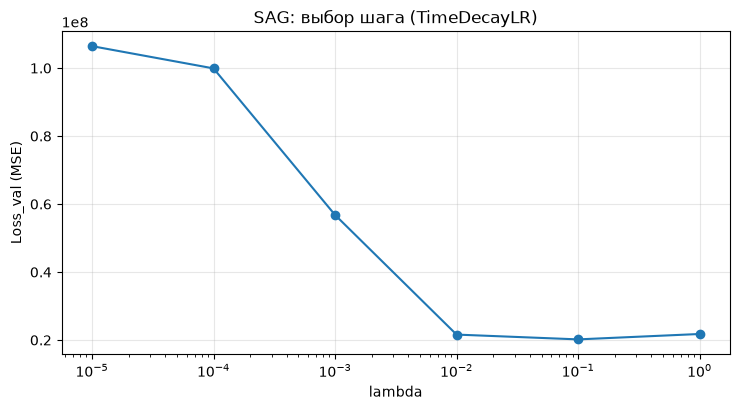

In [10]:
result_sag_decay = investigate("SAG", decay=True)

10. Исследуйте Momentum с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

Momentum — постоянный шаг


step,Loss_train,R²_train,Loss_val
1e-05,"23,932,486.14",0.606777,"23,159,242.94"
0.0001,"18,142,508.73",0.701910,"20,957,736.95"
0.001,"15,198,878.44",0.750275,"18,267,729.21"
0.01,"12,627,120.95",0.792530,"16,694,105.56"
0.1,"12,039,403.41",0.802187,"16,800,319.35"
1,inf,-inf,inf


Лучший шаг по минимальному Loss_val: 0.01
Loss_train = 12,627,120.95
R²_train = 0.792530
Loss_val = 16,694,105.56
Loss_test = 27,835,860.70
R²_test = 0.600848
Число итераций = 5000


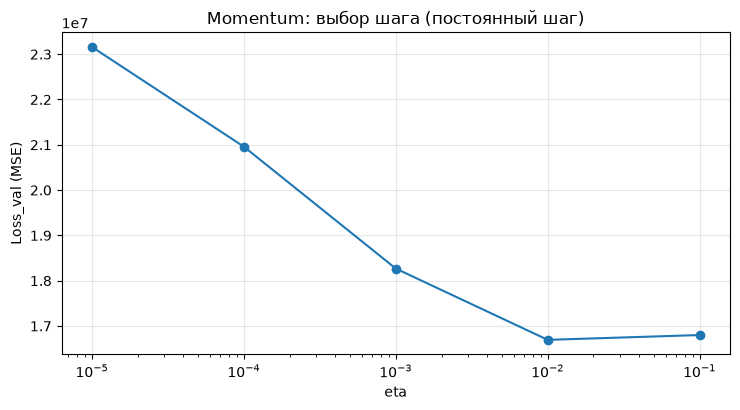

In [11]:
result_momentum_constant = investigate("Momentum", decay=False)

11. Исследуйте Momentum с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

Momentum — TimeDecayLR


step,Loss_train,R²_train,Loss_val
1e-05,"98,403,396.94",-0.616817,"96,203,961.27"
0.0001,"48,196,222.68",0.208112,"45,656,609.65"
0.001,"19,776,419.43",0.675064,"21,356,726.14"
0.01,"17,049,891.39",0.719862,"19,977,224.18"
0.1,"13,734,584.82",0.774334,"17,053,004.61"
1,"12,217,075.74",0.799267,"16,770,145.39"


Лучший шаг по минимальному Loss_val: 1
Loss_train = 12,217,075.74
R²_train = 0.799267
Loss_val = 16,770,145.39
Loss_test = 28,943,881.91
R²_test = 0.584959
Число итераций = 5000


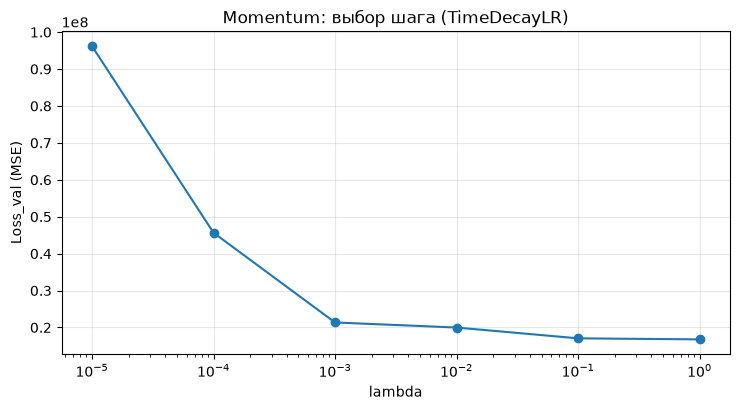

In [12]:
result_momentum_decay = investigate("Momentum", decay=True)

12. Исследуйте Adam с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

Adam — постоянный шаг


step,Loss_train,R²_train,Loss_val
1e-05,"109,269,775.33",-0.795357,"107,206,112.78"
0.0001,"109,214,925.51",-0.794456,"107,150,631.03"
0.001,"108,667,927.90",-0.785468,"106,597,305.47"
0.01,"103,346,929.39",-0.698042,"101,212,240.62"
0.1,"63,662,148.35",-0.046001,"60,904,856.80"
1,"14,406,254.21",0.763298,"17,285,930.86"


Лучший шаг по минимальному Loss_val: 1
Loss_train = 14,406,254.21
R²_train = 0.763298
Loss_val = 17,285,930.86
Loss_test = 25,657,350.91
R²_test = 0.632087
Число итераций = 5000


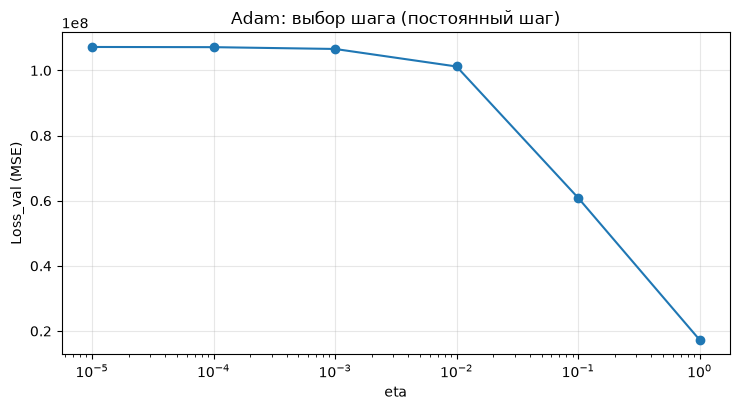

In [13]:
result_adam_constant = investigate("Adam", decay=False)

13. Исследуйте Adam с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

Adam — TimeDecayLR


step,Loss_train,R²_train,Loss_val
1e-05,"109,275,700.78",-0.795454,"107,212,106.48"
0.0001,"109,274,164.88",-0.795429,"107,210,552.89"
0.001,"109,258,807.00",-0.795177,"107,195,018.13"
0.01,"109,105,339.41",-0.792655,"107,039,781.04"
0.1,"107,581,769.79",-0.767622,"105,498,451.27"
1,"93,439,141.20",-0.535252,"91,173,446.86"


Лучший шаг по минимальному Loss_val: 1
Loss_train = 93,439,141.20
R²_train = -0.535252
Loss_val = 91,173,446.86
Loss_test = 112,636,766.80
R²_test = -0.615154
Число итераций = 5000


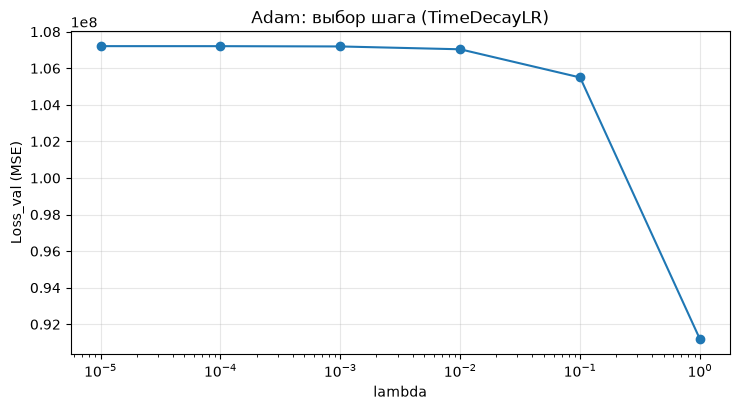

In [14]:
result_adam_decay = investigate("Adam", decay=True)

14. Постройте итоговую сравнительную таблицу со следующими столбцами:

1) название метода

2) значение лучшего шага (если n) или функция лучшего шага (если n(lyamda))

3) Loss_train

4) Loss_test

5) R^2 train

6) R^2 test

7) число итераций на test

Метод,Лучший шаг,Loss_train,Loss_test,R²_train,R²_test,Число итераций на test*
VGD — постоянный шаг,η = 0.1,"12,626,987.61","27,835,243.07",0.79,0.60,5000
VGD — TimeDecayLR,λ = 1; η(k) = 1 / √(1 + k),"13,736,414.90","26,457,141.65",0.77,0.62,5000
SGD — постоянный шаг,η = 0.1,"13,180,140.32","28,269,777.97",0.78,0.59,5000
SGD — TimeDecayLR,λ = 0.1; η(k) = 0.1 / √(1 + k),"17,040,102.42","24,700,352.51",0.72,0.65,5000
SAG — постоянный шаг,η = 0.01,"16,358,293.52","26,571,773.98",0.73,0.62,5000
SAG — TimeDecayLR,λ = 0.1; η(k) = 0.1 / √(1 + k),"17,636,107.64","25,314,804.42",0.71,0.64,5000
Momentum — постоянный шаг,η = 0.01,"12,627,120.95","27,835,860.70",0.79,0.60,5000
Momentum — TimeDecayLR,λ = 1; η(k) = 1 / √(1 + k),"12,217,075.74","28,943,881.91",0.80,0.58,5000
Adam — постоянный шаг,η = 1,"14,406,254.21","25,657,350.91",0.76,0.63,5000
Adam — TimeDecayLR,λ = 1; η(k) = 1 / √(1 + k),"93,439,141.20","112,636,766.80",-0.54,-0.62,5000


* Здесь указано число итераций ОБУЧЕНИЯ выбранной модели.
На test веса не меняются: выполняются предсказание и расчёт метрик.


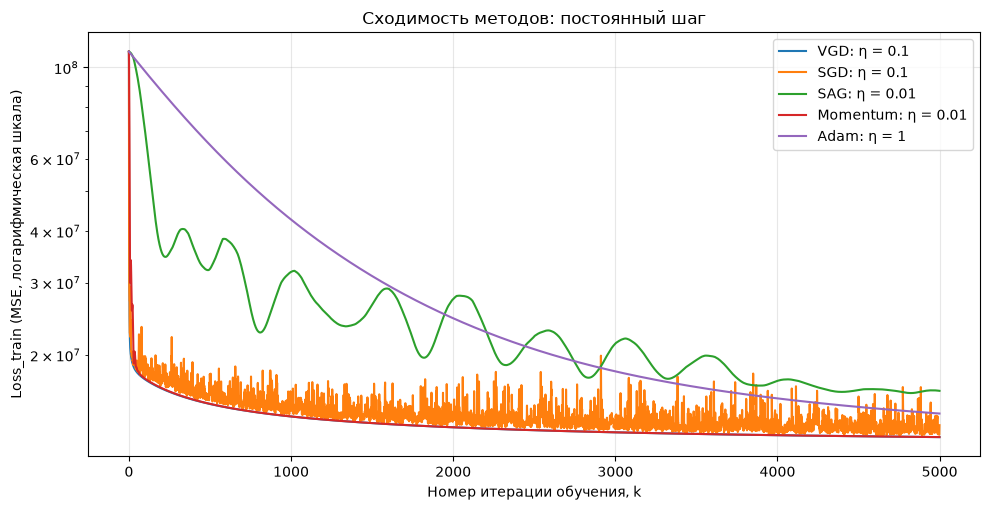

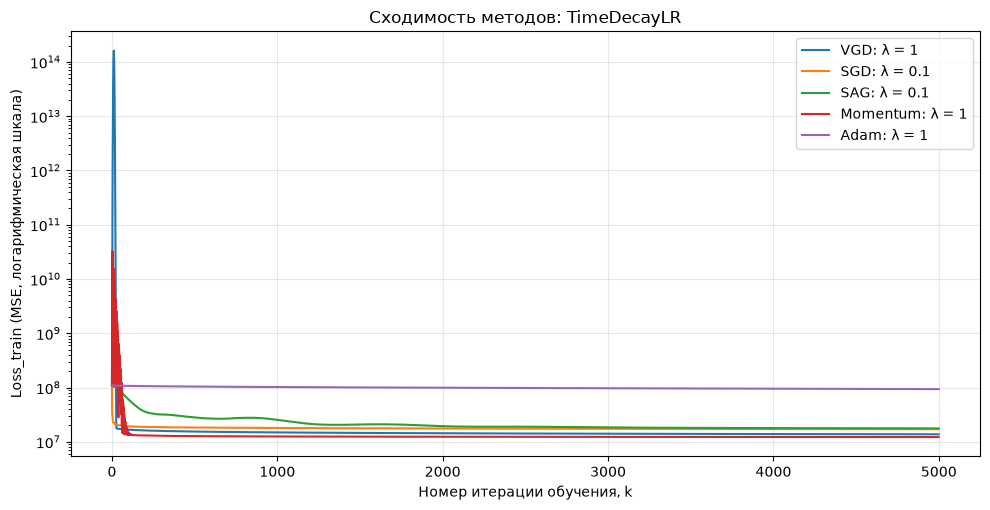

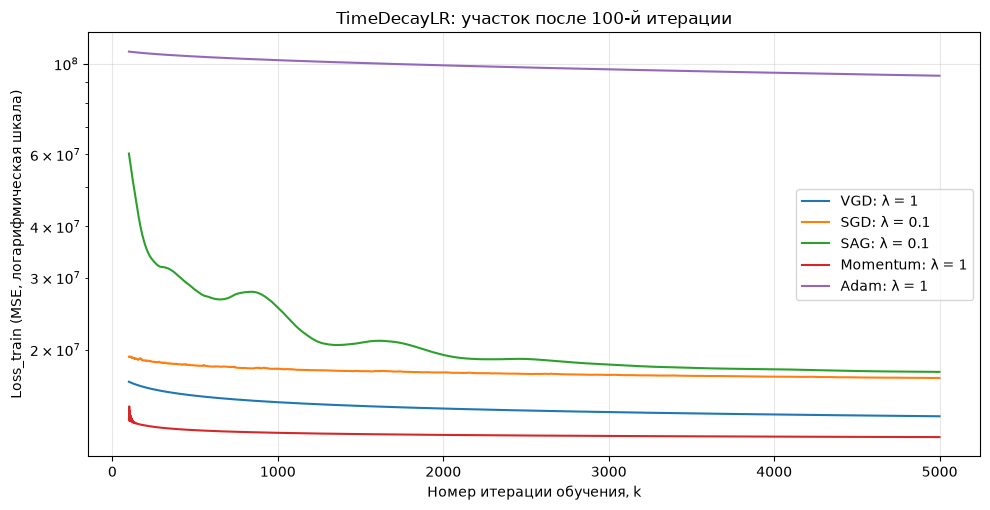

In [16]:
summary_rows = []
for (method, decay), result in experiments.items():
    step = result["best_step"]
    step_description = (
        f"λ = {step:g}; η(k) = {step:g} / √(1 + k)"
        if decay else f"η = {step:g}"
    )
    summary_rows.append({
        "Метод": f"{method} — " + ("TimeDecayLR" if decay else "постоянный шаг"),
        "Лучший шаг": step_description,
        "Loss_train": result["Loss_train"],
        "Loss_test": result["Loss_test"],
        "R²_train": result["R²_train"],
        "R²_test": result["R²_test"],
        "Число итераций на test*": result["iterations"],
    })

comparison_table = pd.DataFrame(summary_rows)
display(comparison_table.style.format({
    "Loss_train": "{:,.2f}", "Loss_test": "{:,.2f}",
    "R²_train": "{:.2f}", "R²_test": "{:.2f}",
}).hide(axis="index"))
print("* Здесь указано число итераций ОБУЧЕНИЯ выбранной модели.")
print("На test веса не меняются: выполняются предсказание и расчёт метрик.")

# Как в лекции: сравниваем Loss_train на каждой итерации.
# Для постоянного шага и TimeDecayLR строим отдельные общие графики.
for decay in (False, True):
    plt.figure(figsize=(10, 5.2))
    for method in ("VGD", "SGD", "SAG", "Momentum", "Adam"):
        result = experiments[(method, decay)]
        history = result["best_model"].loss_history_
        step_symbol = "λ" if decay else "η"
        plt.plot(np.arange(len(history)), history,
                 label=f"{method}: {step_symbol} = {result['best_step']:g}")
    plt.yscale("log")
    plt.xlabel("Номер итерации обучения, k")
    plt.ylabel("Loss_train (MSE, логарифмическая шкала)")
    plt.title("Сходимость методов: " + ("TimeDecayLR" if decay else "постоянный шаг"))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Начальный всплеск ошибки у некоторых методов с lambda=1 сжимает
# остальные кривые. Отдельно показываем тот же график после 100-го шага.
plt.figure(figsize=(10, 5.2))
for method in ("VGD", "SGD", "SAG", "Momentum", "Adam"):
    result = experiments[(method, True)]
    history = np.asarray(result["best_model"].loss_history_)
    start = min(100, len(history) - 1)
    plt.plot(np.arange(start, len(history)), history[start:],
             label=f"{method}: λ = {result['best_step']:g}")
plt.yscale("log")
plt.xlabel("Номер итерации обучения, k")
plt.ylabel("Loss_train (MSE, логарифмическая шкала)")
plt.title("TimeDecayLR: участок после 100-й итерации")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

15. Сделайте вывод о том, какой метод и шаг линейной регрессии самый лучший для данной выборки и ответьте на вопросы:

1) почему именно этот метод и этот шаг самый лучший (по каким данным из таблицы вы сделали такой вывод)

2) расскажите простыми словами суть R^2_train и R^2_test?

3) как R^2_train и R^2_test помогают сравнивать методы? почему оба эти значения надо вычислять для данного выбора?

### 15. Сделайте вывод о том, какой метод и шаг линейной регрессии самый лучший для данной выборки и ответьте на вопросы:

#### 1) Почему именно этот метод и этот шаг самый лучший (по каким данным из таблицы вы сделали такой вывод)?

Самым лучшим оказался **SGD с TimeDecayLR при lambda = 0.1**.

Я сделал такой вывод потому, что именно у этого метода получился самый маленький Loss_test и самый большой R²_test среди всех вариантов. То есть на тестовой выборке этот вариант показал лучшее качество на новых данных, которые модель до этого не видела.

Само значение **lambda = 0.1** я выбрал потому, что при нём на валидационной выборке при нем был минимальный Loss_val.

#### 2) Расскажите простыми словами суть R²_train и R²_test?

**R²_train** показывает качество модели на данных, на которых она обучалась, а **R²_test** — качество этой же модели на новых данных, которые она при обучении не видела.

Чем больше значение R², тем лучше модель показывает себя на соответствующей выборке.

Если R² близок к 1, значит модель работает очень хорошо.  
Если R² около 0, значит модель почти не лучше простого предсказания среднего значения.  
Если R² меньше 0, значит модель работает плохо и даже хуже, чем если бы мы просто предсказывали среднее значение.

#### 3) Как R²_train и R²_test помогают сравнивать методы? Почему оба эти значения надо вычислять для данного выбора?

Оба значения нужны, чтобы сравнивать методы не только по тому, как хорошо они работают на обучающей выборке, но и по тому, насколько хорошо это качество сохраняется на тестовой выборке.

Если смотреть только на R²_train, можно выбрать метод, который хорошо показывает себя на данных, на которых обучался, но хуже работает на новых данных. Поэтому при итоговом выборе особенно важен R²_test: чем он больше, тем лучше качество модели на новых данных.

Если R²_train высокий и R²_test тоже высокий, значит модель хорошо работает и на обучающих, и на новых данных.

Если R²_train высокий, а R²_test заметно ниже, значит модель хорошо показывает себя на обучении, но хуже переносит результат на новые данные.

Если оба значения низкие, значит модель в целом плохо описывает зависимость и на обучающей, и на тестовой выборке.
